# Spurious fixed points and finite-N dynamics

Asks whether the network's attractor is only the encoded ring or whether other stable
states exist, approached from two directions: initial conditions far off the ring, and
networks too small to support a continuous attractor.

**Produces** Supplementary Figures S11 (`spurious_fixed_points.pdf`) and S12
(`finite_size_dynamics.pdf`).

**Reads** `data/mouse_data/tc_data.npz` and `data/spurious_fixed_points.npz`.

In [1]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
SAVE_FIGURES = False
REGENERATE_CACHES = False

import numpy as np
from ring import data_driven, sim
from tqdm import tqdm
import matplotlib.pyplot as plt
from ring import style
from ring.seed import set_global_seed
import scipy
import torch
import numpy as np
import torch
import scipy
import scipy.linalg
from ring import sim
from ring import data_driven
from ring.fn import nonlin_idealized
from ring.tc import gen_tuning_curves_idealized

## Supplementary Figure S11: searching for spurious fixed points

Runs the N=2500 network from initial conditions drawn at increasing noise scale (std 1 to 1000, far outside the encoded manifold) and projects the initial and final states onto the first two PCs of the tuning-curve matrix. States collapse back onto the ring at every scale; no spurious attractors are found. The `plt.savefig` sits inside `spurious_analysis()` with no check of its own, and the call to that function at the bottom of the cell only runs when `REGENERATE_CACHES = True`, so re-running the notebook does not overwrite the committed figure. The seeds at the top of the function body make the output deterministic.

In [2]:
def compute_spurious_analysis(save_path="../data/spurious_fixed_points.npz"):
    """Spurious-fixed-point search: run the finite-N dynamics from noisy initial
    conditions and cache the PC-projected initial and final states.

    Standard producer/consumer split (matches every other multi-minute figure):
    this REGENERATE_CACHES-gated cell writes the .npz; the SAVE_FIGURES-gated plot
    cell below reads it. ~2 min on CPU, so cached rather than recomputed each run.
    Fully deterministic via ring.seed.set_global_seed(42), the one seeding entry
    point used across the repo.
    """
    set_global_seed(42)

    N              = 2500
    N_theta        = 500
    beta           = 2.7659
    scale          = 1.4211
    lamda          = 1e-8
    device         = 'cuda' if torch.cuda.is_available() else 'cpu'
    T_total        = 30.0
    tau            = 0.050
    dt             = tau / 10.0
    T_eval         = 0.1
    N_init         = 34
    phi_fn         = lambda x: nonlin_idealized(x, beta=beta)

    # Build J from idealized tuning curves, then the PCA basis of the tuning space.
    X, Phi = gen_tuning_curves_idealized(
        N_samples=N, N_theta=N_theta, scale=scale, beta=beta
    )
    J, _ = data_driven.compute_weights(X=X, Phi=Phi, lamda=lamda)
    mu = X.mean(0)
    U, s, Vt = np.linalg.svd(X - mu)
    V = Vt.T
    pcs = (X - mu) @ V

    # Sweep the initial-condition noise scale; project init and final states onto PCs.
    std_values = np.array([1, 10, 50, 100, 1000])
    inits, finals = [], []
    for std_val in std_values:
        theta_idx = (np.arange(N_init) * N_theta / N_init).round().astype(int)
        x_init = X[theta_idx].T
        x0_dis_noisy = np.random.randn(*x_init.shape) * std_val
        x_dyn_final, X_dyn, finished = sim.run_sim(
            T=T_total, tau=tau, dt=dt, T_eval=T_eval,
            J=torch.Tensor(J).to(device),
            x_init=torch.Tensor(x0_dis_noisy).to(device),
            nonlin=phi_fn, break_if_stopped=False,
        )
        inits.append((X_dyn[0].T - mu) @ V)
        finals.append((x_dyn_final.T - mu) @ V)

    # --- Second row: the DATA-DERIVED (Setting 1) network -------------------
    # The main-text global-stability claim is about this network, but the figure
    # only ever showed the generative one. Same protocol, same noise levels.
    set_global_seed(42)
    Phi_raw = data_driven.load_data_Phi()
    X_dd, Phi_dd = data_driven.prepare_smoothed_normalized_resampled_tuning_curves(
        Phi_raw, N_theta=10000
    )
    J_dd, _ = data_driven.compute_weights(X_dd, Phi_dd, lamda=lamda)
    mu_dd = X_dd.mean(0)
    # full_matrices=False: X_dd is 10000 x N_data, so the full U would be 10000 x 10000.
    U_dd, s_dd, Vt_dd = np.linalg.svd(X_dd - mu_dd, full_matrices=False)
    V_dd = Vt_dd.T
    pcs_dd = (X_dd - mu_dd) @ V_dd

    inits_dd, finals_dd = [], []
    for std_val in std_values:
        x0_dd = np.random.randn(X_dd.shape[1], N_init) * std_val
        x_dd_final, X_dd_dyn, _ = sim.run_sim(
            T=T_total, tau=tau, dt=dt, T_eval=T_eval,
            J=torch.Tensor(J_dd).to(device),
            x_init=torch.Tensor(x0_dd).to(device),
            nonlin=data_driven.nonlin,
            target_mean=1.0, const=1.0,   # Setting 1 carries the uniform inhibition
            break_if_stopped=False,
        )
        inits_dd.append((X_dd_dyn[0].T - mu_dd) @ V_dd)
        finals_dd.append((x_dd_final.T - mu_dd) @ V_dd)

    np.savez(save_path, pcs=pcs, std_values=std_values,
             inits=np.array(inits), finals=np.array(finals),
             pcs_dd=pcs_dd, inits_dd=np.array(inits_dd), finals_dd=np.array(finals_dd))


if REGENERATE_CACHES:
    compute_spurious_analysis()

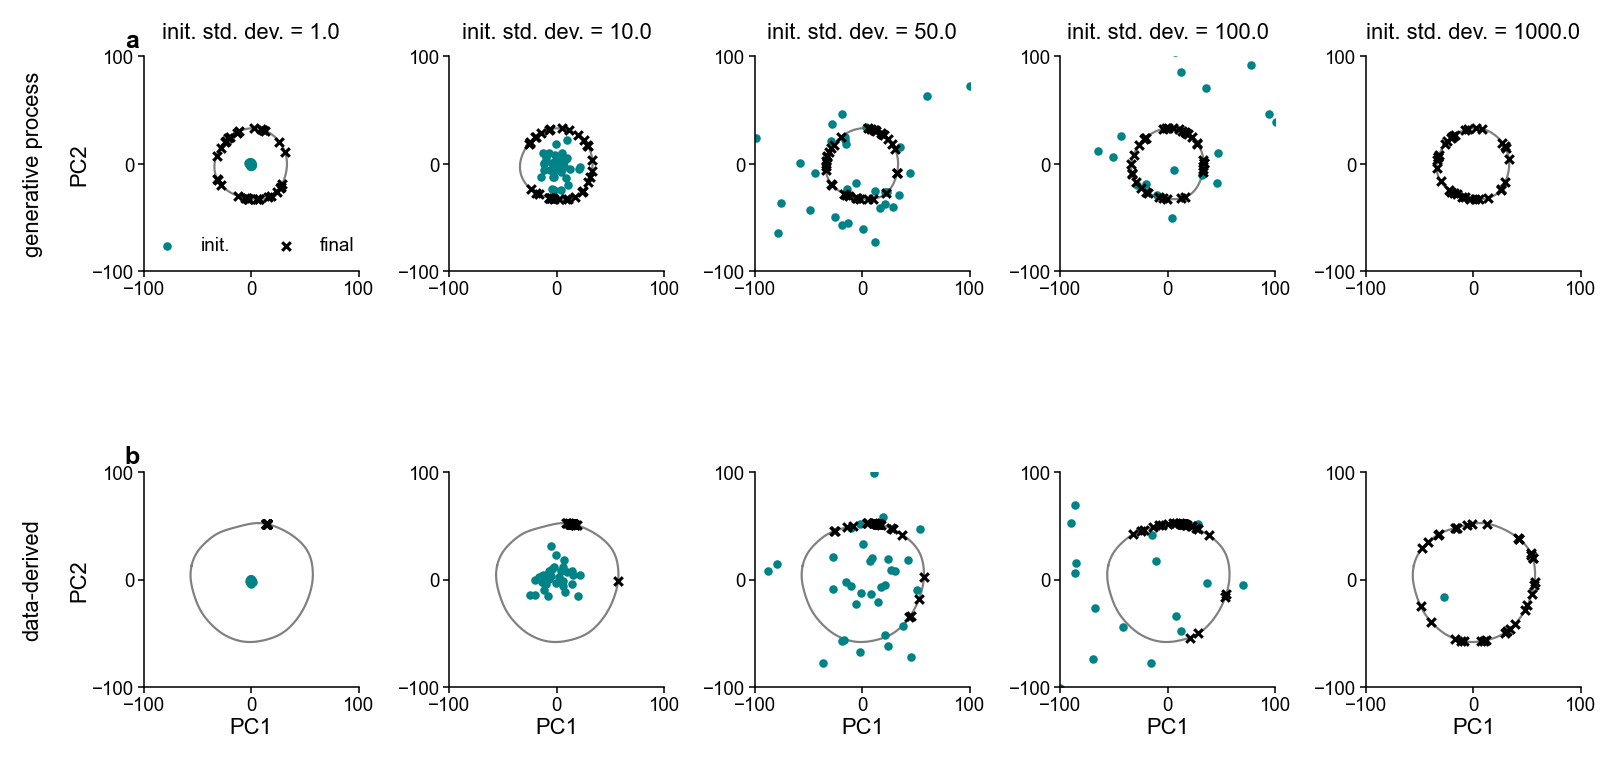

In [3]:
# Plot cell: reads the cache written above and draws the figure. Two rows, one per
# model setting, at the same five initial-condition noise levels.
_d = np.load("../data/spurious_fixed_points.npz")
pcs, std_values = _d["pcs"], _d["std_values"]
inits, finals = _d["inits"], _d["finals"]
pcs_dd, inits_dd, finals_dd = _d["pcs_dd"], _d["inits_dd"], _d["finals_dd"]

rows = [
    ("a", "generative process", pcs, inits, finals, 100),
    ("b", "data-derived", pcs_dd, inits_dd, finals_dd, None),
]
fig, axes = plt.subplots(2, 5, figsize=(style.FULL_W, 4))
for r, (letter, label, P, I, F, lim) in enumerate(rows):
    if lim is None:
        # scale to the ring itself, so the two rows are each readable on their own terms
        lim = float(np.ceil(1.6 * np.abs(P[:, :2]).max() / 10) * 10)
    for idx, std_val in enumerate(std_values):
        ax = axes[r, idx]
        ax.plot(P[:, 0], P[:, 1], zorder=0, c='0.5')
        ax.scatter(I[idx][:, 0], I[idx][:, 1], lw=0, s=7.5, color=style.BLUE, label='init.')
        ax.scatter(F[idx][:, 0], F[idx][:, 1], lw=1, s=7.5, marker='x', c='black', label='final')
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect(1.)
        ax.set_xticks([-lim, 0, lim])
        ax.set_yticks([-lim, 0, lim])
        if r == 0:
            ax.set_title(f"init. std. dev. = {std_val:.1f}")
        if r == len(rows) - 1:
            ax.set_xlabel("PC1")
        if idx == 0:
            # the setting name rides on the ylabel so it cannot collide with the legend
            ax.set_ylabel(f"{label}\n\nPC2")
            style.panel_letter(ax, letter)
            if r == 0:
                ax.legend(loc='lower center', ncol=2)

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/spurious_fixed_points.pdf", bbox_inches='tight')
plt.show()


## Supplementary Figure S12: the attractor at finite N

Repeats the search across shrinking population sizes (N = 50 to 1000) with small initial perturbations. As N falls the continuous ring breaks up into isolated fixed points, showing the attractor is an emergent large-N property. The `np.random.seed(42)` / `torch.manual_seed(42)` / `torch.cuda.manual_seed_all(42)` block is set before any code that draws random numbers, which is why this figure regenerates exactly. `plt.savefig("finite_size_dynamics.pdf")` only runs when `SAVE_FIGURES = True`, so a normal run leaves the committed image alone.

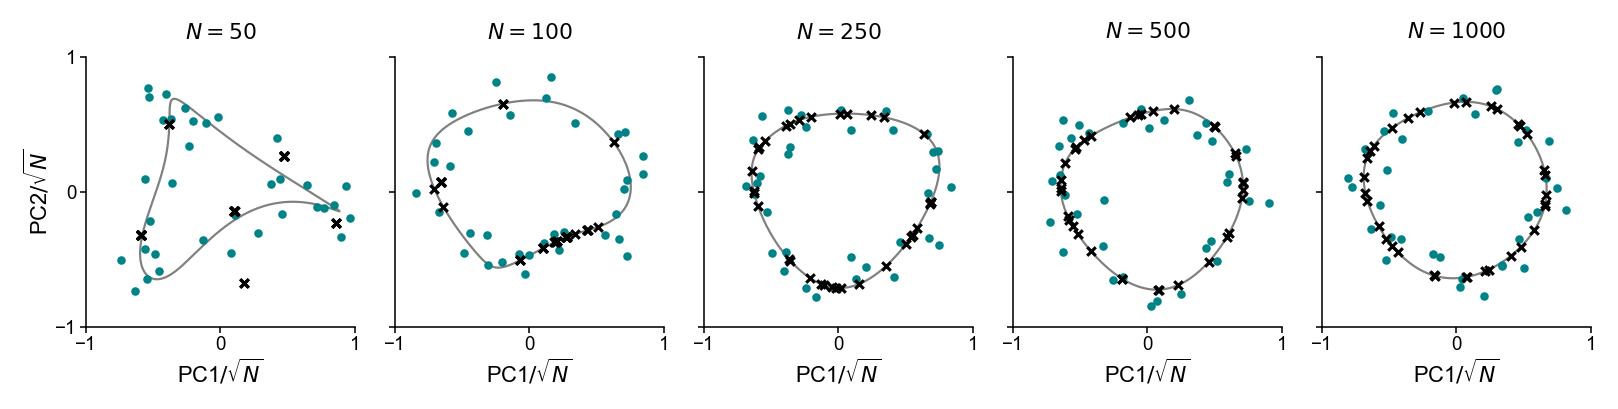

In [4]:
# ----------------------------
# Params
# ----------------------------
N_vals         = [50, 100, 250, 500, 1000]
N_theta        = 500
beta           = 2.7659
scale          = 1.4211
lamda          = 1e-8
device         = 'cuda' if torch.cuda.is_available() else 'cpu'
# Dynamics
T_total        = 30.0
tau            = 0.050
dt             = tau / 10.0
T_eval         = 0.1
phi_fn         = lambda x: nonlin_idealized(x, beta=beta)  # defined elsewhere
# Initial condition count
N_init         = 34
std_val = 0.1

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

_panels = []
for N_idx, N in enumerate(N_vals):
    # ----------------------------
    # Build J 
    # ----------------------------
    X, Phi = gen_tuning_curves_idealized(
        N_samples=N, N_theta=N_theta, scale=scale, beta=beta
    )
    J, _ = data_driven.compute_weights(X=X, Phi=Phi, lamda=lamda)
    
    # ----------------------------
    # Compute PCA basis
    # ----------------------------
    mu = X.mean(0)
    X_ctd = X - mu
    U, s, Vt = np.linalg.svd(X_ctd)
    V = Vt.T
    pcs = X_ctd @ V
    
    # ----------------------------
    # Construct initial conditions
    # ----------------------------
    theta_idx = (np.arange(N_init) * N_theta / N_init).round().astype(int)
    x_init = X[theta_idx].T
    x0_dis_noisy = x_init + np.random.randn(*x_init.shape) * std_val * np.sqrt(N)
    
    # Run simulation
    x_dyn_final, X_dyn, finished = sim.run_sim(
        T=T_total,
        tau=tau,
        dt=dt,
        T_eval=T_eval,
        J=torch.Tensor(J).to(device),
        x_init=torch.Tensor(x0_dis_noisy).to(device),
        nonlin=phi_fn,
        break_if_stopped=False,
    )
    
    # Project onto PCs
    init_state_proj = (X_dyn[0].T - mu) @ V
    final_state_proj = (x_dyn_final.T - mu) @ V
    
    # Projections grow as sqrt(N), so store them rescaled. Without this the five
    # panels cannot share an axis limit, and per-panel autoscaling hides the very
    # thing the figure exists to show, namely that the manifold tightens into a
    # clean ring as N grows. Main-text Fig. 2f divides by sqrt(N) for the same
    # reason.
    _rt = np.sqrt(N)
    _panels.append((N, pcs[:, :2] / _rt, init_state_proj[:, :2] / _rt, final_state_proj[:, :2] / _rt))

# --- plot ---
# One limit for all five panels, rounded up to a clean number so the tick labels
# are readable, matching how the sibling figure in this notebook sets its rows.
_lim = float(np.ceil(1.1 * max(np.abs(p).max() for _, p, _, _ in _panels) * 10) / 10)

fig, axes = plt.subplots(1, len(N_vals), figsize=(style.FULL_W, 2))
for idx, (N, P, I, F) in enumerate(_panels):
    ax = axes[idx]
    ax.plot(P[:, 0], P[:, 1], zorder=0, c='0.5')
    ax.scatter(I[:, 0], I[:, 1], lw=0, s=7.5, color=style.BLUE, label='init.')
    ax.scatter(F[:, 0], F[:, 1], lw=1, s=7.5, marker='x', c='black', label='final')
    ax.set_xlim(-_lim, _lim)
    ax.set_ylim(-_lim, _lim)
    ax.set_aspect(1.)
    ax.set_xticks([-_lim, 0, _lim])
    ax.set_yticks([-_lim, 0, _lim])
    ax.set_title("$N = {}$".format(N))
    ax.set_xlabel(r"PC1$/\sqrt{N}$")
    if idx == 0:
        ax.set_ylabel(r"PC2$/\sqrt{N}$")
    else:
        ax.set_yticklabels([])

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig("../figures/finite_size_dynamics.pdf", bbox_inches='tight')